# データの読み込み

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [32]:
# ライブラリをインポート
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# DataSample.xlsx の読み込み
df = pd.read_excel('/content/drive/My Drive/Colab Notebooks/DataSample.xlsx')
df

,ID,Gender,GPA,Attendance,Japanese,English,Mathematics,Prefecture
0,1,M,1.355,0.58,64.0,7.0,35.0,長崎県
1,2,F,1.847,0.65,NaN,NaN,NaN,福岡県
2,3,M,3.261,0.96,62.0,63.0,30.0,福岡県
3,4,M,2.320,0.93,58.0,56.0,45.0,福岡県
4,5,F,0.000,0.30,70.0,26.0,40.0,福岡県
...,...,...,...,...,...,...,...,...
516,517,M,2.419,0.83,70.0,85.0,NaN,熊本県
517,518,M,1.716,0.84,62.0,12.0,NaN,福岡県
518,519,M,1.629,0.88,42.0,16.0,NaN,福岡県
519,520,M,1.490,0.78,56.0,NaN,NaN,福岡県


In [33]:
# 基本統計量を表示
df.describe()

,ID,GPA,Attendance,Japanese,English,Mathematics
count,521.000000,521.000000,521.000000,495.000000,493.000000,217.000000
mean,261.000000,1.977735,0.805451,55.557576,38.880325,39.451613
std,150.544013,0.766971,0.129656,13.800495,25.320544,21.797866
min,1.000000,0.000000,0.200000,19.000000,0.000000,0.000000
25%,131.000000,1.400000,0.730000,46.000000,19.000000,20.000000
50%,261.000000,1.909000,0.830000,56.000000,37.000000,40.000000
75%,391.000000,2.471000,0.900000,66.000000,57.000000,55.000000
max,521.000000,3.786000,0.990000,88.000000,98.000000,100.000000


In [34]:
# 欠損値の確認
df.isnull().sum()


ID               0
Gender           0
GPA              0
Attendance       0
Japanese        26
English         28
Mathematics    304
Prefecture       0
dtype: int64

In [35]:
# 欠損値を含む行を削除
df = df.dropna(how='any')
# 状態の確認
print(df.shape)
df.isnull().sum()

(216, 8)


ID             0
Gender         0
GPA            0
Attendance     0
Japanese       0
English        0
Mathematics    0
Prefecture     0
dtype: int64

# データの視覚化


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f567a9a7e48>,
      dtype=object)

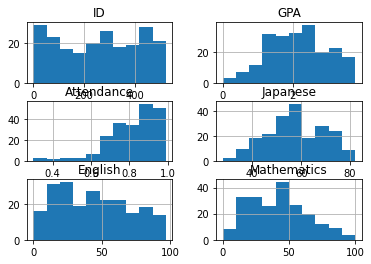

In [36]:
# pandas > matplotlib でヒストグラムの一括表示
df.hist( )

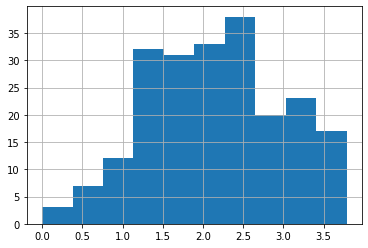

In [13]:
# pandas > matplotlib で GPA のヒストグラムの表示
df["GPA"] .hist( )

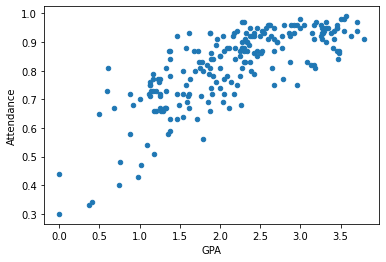

In [ ]:
# pandas > matplotlib で GPA と Attendance の相関を散布図で確認
df.plot.scatter(x='GPA', y='Attendance')

## ライブラリ seaborn の利用
* 量的変数の分布 ＞ distplot 関数
* 質的変数の度数分布 ＞ countplot 関数

In [48]:
import warnings
warnings.resetwarnings()
warnings.simplefilter('ignore', FutureWarning)
warnings.simplefilter('ignore', RuntimeWarning)

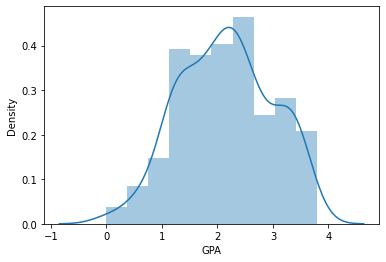

In [41]:
# seaborn のdistplot  関数でヒストグラムを描画
sns.distplot( df["GPA"] )

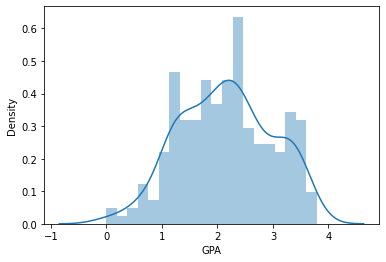

In [42]:
# seaborn のdistplot  関数でヒストグラムを描画（bins を増やして区切りを細かく）
sns.distplot( df["GPA"] , bins=20 )

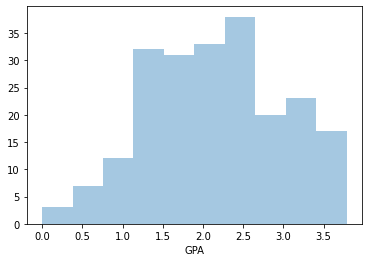

In [43]:
# seaborn の distplot  関数でヒストグラムを描画（カーネル密度関数をOFF）
sns.distplot( df["GPA"] , kde=False )

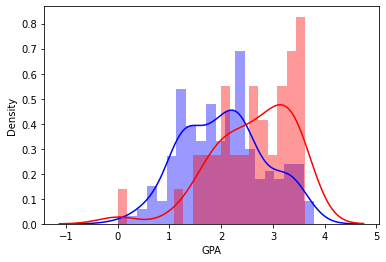

In [44]:
# seaborn の distplot  関数で２つのヒストグラムを表示する
df_m = df[ df["Gender"] == "M" ]
df_f = df[ df["Gender"] == "F" ]
sns.distplot(df_m["GPA"] , bins=20, color ="b" )
sns.distplot(df_f["GPA"] , bins=20, color ="r" )

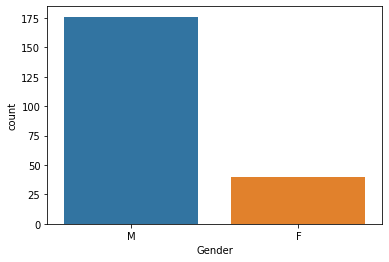

In [45]:
#  seaborn の countplot  関数で度数を表示
sns.countplot( x="Gender", data = df )

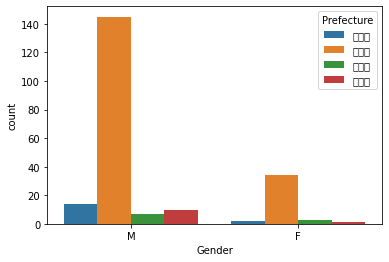

In [49]:
#  seaborn の countplot  関数で、色分け表示
sns.countplot( x="Gender", hue="Prefecture", data = df )

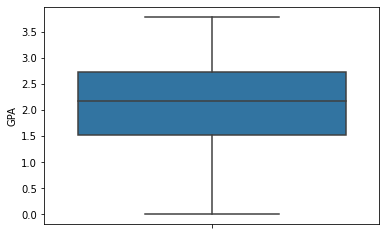

In [24]:
#  seaborn の boxplot  関数で、ボックスプロット
sns.boxplot( y ="GPA", data =df )

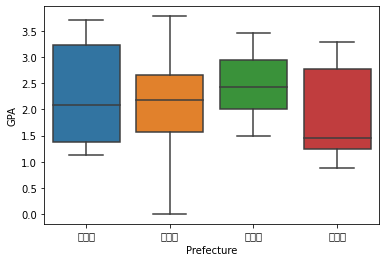

In [50]:
#  seaborn の boxplot  関数で、複数のデータを比較
sns.boxplot( x = "Prefecture", y = "GPA", data =df )